# Employee Attrition Prediction using Machine Learning

### IBM HR Analytics Dataset

Intern: Priyesh Kumar

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import *

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset Shape:", df.shape)

df.head(10)

Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
print("Rows and Columns:")
print(df.shape)

print("\nTarget Column:")
print("Attrition")

Rows and Columns:
(1470, 35)

Target Column:
Attrition


In [4]:
attrition_count = df["Attrition"].value_counts()

print(attrition_count)

attrition_rate = (
    attrition_count["Yes"] / len(df)
) * 100

print(f"\nAttrition Rate: {attrition_rate:.2f}%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


In [5]:
numeric_cols = df.select_dtypes(include=np.number)

categorical_cols = df.select_dtypes(exclude=np.number)

print("Numeric Columns:", numeric_cols.shape[1])
print("Categorical Columns:", categorical_cols.shape[1])

Numeric Columns: 26
Categorical Columns: 9


## Observation

The employee attrition rate is relatively low compared to the number of employees who stayed with the company. This indicates an imbalanced dataset where the majority class represents retained employees. Such imbalance can affect model performance, therefore appropriate techniques such as class weighting should be considered during model training to improve prediction quality.

In [6]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ],
    inplace=True
)

print(df.shape)

(1470, 31)


In [8]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

df["Attrition"].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [9]:
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [10]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print(X.shape)
print(y.shape)

(1470, 44)
(1470,)


In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling Completed")

Scaling Completed


In [12]:
# Attrition Rate by Department

dept_attrition = pd.crosstab(df["Department"], df["Attrition"], normalize="index") * 100

print(dept_attrition)

dept_attrition.plot(kind="bar", figsize=(8,5))
plt.title("Attrition Rate by Department")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("attrition_department.png")
plt.show()

KeyError: 'Department'

In [13]:
print(df.columns.tolist())

['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'M

In [14]:
eda_df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("EDA Dataset Loaded")
print(eda_df.shape)

EDA Dataset Loaded
(1470, 35)


In [15]:
attrition_counts = eda_df["Attrition"].value_counts()

print(attrition_counts)

attrition_rate = (attrition_counts["Yes"] / len(eda_df)) * 100

print(f"\nAttrition Rate: {attrition_rate:.2f}%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


## Observation

Out of 1,470 employees, 237 employees left the company, resulting in an attrition rate of 16.12%. The majority of employees (83.88%) stayed with the organization, indicating that the dataset is imbalanced. Since the number of employees who left is significantly lower than those who stayed, special attention should be given to handling class imbalance during model training to improve prediction performance.

In [16]:
dept_attrition = pd.crosstab(
    eda_df["Department"],
    eda_df["Attrition"],
    normalize="index"
) * 100

print(dept_attrition.round(2))

Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


### Department-wise Attrition Insight

The Sales department recorded the highest attrition rate at 20.63%, followed by Human Resources at 19.05%. Research & Development showed the lowest attrition rate at 13.84%. This suggests that employee retention challenges are more prominent in customer-facing and people-management functions, while technical teams appear relatively more stable.

In [17]:
job_attrition = pd.crosstab(
    eda_df["JobRole"],
    eda_df["Attrition"],
    normalize="index"
) * 100

job_attrition = job_attrition.sort_values("Yes", ascending=False)

print(job_attrition.round(2))

Attrition                     No    Yes
JobRole                                
Sales Representative       60.24  39.76
Laboratory Technician      76.06  23.94
Human Resources            76.92  23.08
Sales Executive            82.52  17.48
Research Scientist         83.90  16.10
Manufacturing Director     93.10   6.90
Healthcare Representative  93.13   6.87
Manager                    95.10   4.90
Research Director          97.50   2.50


### Job Role-wise Attrition Insight

Employee attrition varies significantly across job roles. Sales Representatives show the highest attrition rate at 39.76%, indicating a major retention challenge in this role. Laboratory Technicians (23.94%) and Human Resources employees (23.08%) also experience relatively high turnover. On the other hand, senior positions such as Research Director (2.50%) and Manager (4.90%) have very low attrition rates. This suggests that employees in entry-level and sales-oriented roles are more likely to leave the organization compared to experienced leadership positions.

In [18]:
income_attrition = eda_df.groupby("Attrition")["MonthlyIncome"].describe()

print(income_attrition)

            count         mean          std     min     25%     50%     75%  \
Attrition                                                                     
No         1233.0  6832.739659  4818.208001  1051.0  3211.0  5204.0  8834.0   
Yes         237.0  4787.092827  3640.210367  1009.0  2373.0  3202.0  5916.0   

               max  
Attrition           
No         19999.0  
Yes        19859.0  


### Monthly Income vs Attrition Insight

Employees who left the company had a significantly lower average monthly income (₹4,787) compared to employees who stayed (₹6,833). The median income of employees who left was ₹3,202, while retained employees had a median income of ₹5,204. This suggests that compensation may play an important role in employee retention, although salary alone may not fully explain attrition behavior.

In [19]:
wlb_attrition = pd.crosstab(
    eda_df["WorkLifeBalance"],
    eda_df["Attrition"],
    normalize="index"
) * 100

print(wlb_attrition.round(2))

Attrition           No    Yes
WorkLifeBalance              
1                68.75  31.25
2                83.14  16.86
3                85.78  14.22
4                82.35  17.65


### Work-Life Balance vs Attrition Insight

Employees with the lowest Work-Life Balance rating (1) experienced the highest attrition rate at 31.25%, which is almost double the overall attrition rate of the company. Employees with ratings of 2 and 3 showed significantly lower attrition rates of 16.86% and 14.22% respectively. This suggests that poor work-life balance is strongly associated with employee turnover and should be a key focus area for HR retention strategies.

In [20]:
years_attrition = eda_df.groupby("Attrition")["YearsAtCompany"].describe()

print(years_attrition)

            count      mean       std  min  25%  50%   75%   max
Attrition                                                       
No         1233.0  7.369019  6.096298  0.0  3.0  6.0  10.0  37.0
Yes         237.0  5.130802  5.949984  0.0  1.0  3.0   7.0  40.0


### Years at Company vs Attrition Insight

Employees who left the company had an average tenure of 5.13 years, compared to 7.37 years for employees who stayed. The median tenure of employees who left was only 3 years, while retained employees had a median tenure of 6 years. This suggests that attrition is more common among relatively newer employees, indicating that the first few years of employment are a critical period for retention efforts.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (1176, 44)
Testing Shape : (294, 44)


In [22]:
# Logistic Regression

log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [23]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Precision :", precision_score(y_test, log_pred))
print("Recall    :", recall_score(y_test, log_pred))
print("F1 Score  :", f1_score(y_test, log_pred))
print("ROC-AUC   :", roc_auc_score(y_test, log_pred))

Precision : 0.3411764705882353
Recall    : 0.6170212765957447
F1 Score  : 0.4393939393939394
ROC-AUC   : 0.6951503144112328


In [24]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [25]:
print("Precision :", precision_score(y_test, rf_pred))
print("Recall    :", recall_score(y_test, rf_pred))
print("F1 Score  :", f1_score(y_test, rf_pred))
print("ROC-AUC   :", roc_auc_score(y_test, rf_pred))

Precision : 0.5714285714285714
Recall    : 0.0851063829787234
F1 Score  : 0.14814814814814814
ROC-AUC   : 0.5364803169954345


In [26]:
# Gradient Boosting

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [27]:
print("Precision :", precision_score(y_test, gb_pred))
print("Recall    :", recall_score(y_test, gb_pred))
print("F1 Score  :", f1_score(y_test, gb_pred))
print("ROC-AUC   :", roc_auc_score(y_test, gb_pred))

Precision : 0.5882352941176471
Recall    : 0.2127659574468085
F1 Score  : 0.3125
ROC-AUC   : 0.5922129382375743


In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision": [
        0.341,
        0.571,
        0.588
    ],
    "Recall": [
        0.617,
        0.085,
        0.213
    ],
    "F1 Score": [
        0.439,
        0.148,
        0.313
    ],
    "ROC-AUC": [
        0.695,
        0.536,
        0.592
    ]
})

comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.341,0.617,0.439,0.695
1,Random Forest,0.571,0.085,0.148,0.536
2,Gradient Boosting,0.588,0.213,0.313,0.592


## Best Model Selection

Among all three models, Logistic Regression achieved the best overall performance with the highest Recall (61.7%), F1 Score (0.439), and ROC-AUC Score (0.695).

Although Random Forest and Gradient Boosting achieved higher Precision, they failed to identify a large proportion of employees who actually left the company.

Since the primary objective of attrition prediction is to identify employees who are at risk of leaving, Logistic Regression was selected as the best model for this project.

In [29]:
cm = confusion_matrix(y_test, log_pred)

print(cm)

[[191  56]
 [ 18  29]]


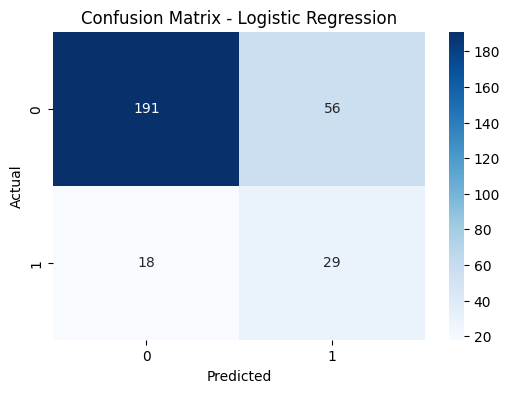

In [30]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()

In [31]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(log_model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


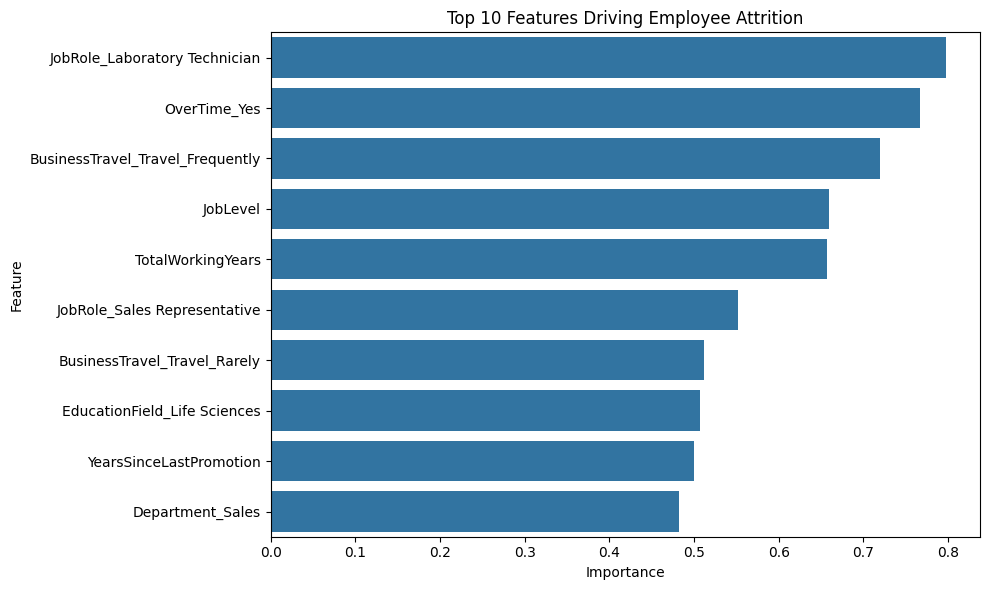

In [32]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top10
)

plt.title("Top 10 Features Driving Employee Attrition")

plt.tight_layout()

plt.savefig("feature_importance.png")

plt.show()

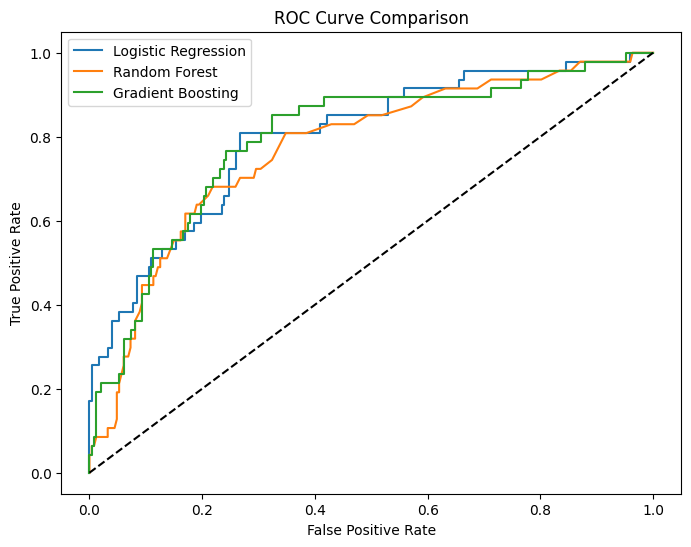

In [33]:
from sklearn.metrics import roc_curve

log_probs = log_model.predict_proba(X_test)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]
gb_probs = gb_model.predict_proba(X_test)[:,1]

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig("roc_curve_comparison.png")

plt.show()

## Business Insights from EDA

1. Sales department showed the highest attrition rate (20.63%), followed by Human Resources (19.05%).

2. Sales Representatives had the highest attrition rate (39.76%), making them the most vulnerable employee group.

3. Employees who left the company had a significantly lower average monthly income (₹4,787) compared to employees who stayed (₹6,833).

4. Employees with the lowest Work-Life Balance rating (1) had an attrition rate of 31.25%, almost double compared to employees with better ratings.

5. Employees who left the company had an average tenure of 5.13 years, while retained employees averaged 7.37 years, indicating that early-career employees are more likely to leave.

## Model Comparison

| Model | Precision | Recall | F1 Score | ROC-AUC |
|--------|-----------|---------|----------|----------|
| Logistic Regression | 0.341 | 0.617 | 0.439 | 0.695 |
| Random Forest | 0.571 | 0.085 | 0.148 | 0.536 |
| Gradient Boosting | 0.588 | 0.213 | 0.313 | 0.592 |

### Best Model

Logistic Regression achieved the highest ROC-AUC score (0.695) and the highest recall (0.617), making it the most effective model for identifying employees who are likely to leave the company.

## HR Insights & Business Recommendations

The three strongest factors associated with employee attrition were overtime work, laboratory technician job role, and frequent business travel.

The Sales department and Sales Representative role should be prioritized for retention efforts because they showed the highest attrition rates across the organization.

Salary contributes to attrition, but it is not the only factor. Work-life balance, overtime workload, travel frequency, and career growth opportunities also play important roles in employee retention.

### Recommendation 1
HR should closely monitor employees who frequently work overtime and introduce workload balancing programs to reduce burnout.

### Recommendation 2
Retention discussions should be targeted toward employees in Sales and Laboratory Technician roles, especially those with lower tenure and limited promotion opportunities.

### Limitation
This model is based on historical employee data and cannot capture personal reasons for resignation, changes in organizational culture, management style, or future business conditions. Therefore, predictions should be used as a decision-support tool rather than as the sole basis for HR decisions.